In [44]:
from sklearn.datasets import make_blobs

In [45]:
x, y = make_blobs(n_samples=500, n_features=2, centers=3, shuffle=True, cluster_std=0.3)

In [46]:
x[:4],y[:15]

(array([[-2.37921365,  8.28015307],
        [-2.89900353,  8.66320048],
        [-2.54734894,  9.30298738],
        [-3.03512528, -9.61273013]]),
 array([1, 1, 1, 2, 0, 0, 2, 2, 1, 1, 2, 2, 0, 0, 1]))

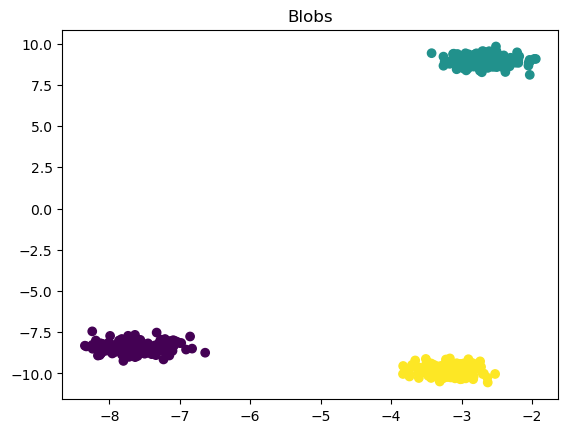

In [47]:
import matplotlib.pyplot as plt

plt.scatter(x[:,0], x[:, 1], c=y)
plt.title("Blobs")
plt.show()

In [48]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [49]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [50]:
import warnings

warnings.filterwarnings("ignore")

In [51]:
model = Sequential()
model.add(Dense(units=24, activation="relu", input_shape=(2,)))
model.add(Dense(units=24, activation="relu"))
model.add(Dense(units=3, activation="softmax"))

In [52]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()
y_train_encoded = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_encoded = encoder.transform(y_test.reshape(-1, 1))

In [53]:
model.compile(optimizer="Adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [54]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 24)             │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 24)             │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │            75 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 747 (2.92 KB)

 Trainable params: 747 (2.92 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
history = model.fit(x_train, y_train, epochs=10, validation_steps=x_test)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3450 - loss: 1.8352
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4700 - loss: 0.9189 
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9975 - loss: 0.4915  
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.3077 
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.2079 
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.1443 
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.1035 
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0777 
Epoch 9/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0606 
Epoch 10/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0483 


In [56]:
Accuracy = history.history['accuracy']
Loss = history.history['loss']
Accuracy[:5], Loss[:5]

([0.3449999988079071, 0.4699999988079071, 0.9975000023841858, 1.0, 1.0],
 [1.8351608514785767,
  0.9189191460609436,
  0.4914894104003906,
  0.3077026605606079,
  0.2078883796930313])

In [57]:
Epoch = list(range(1, 11))
Epoch

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

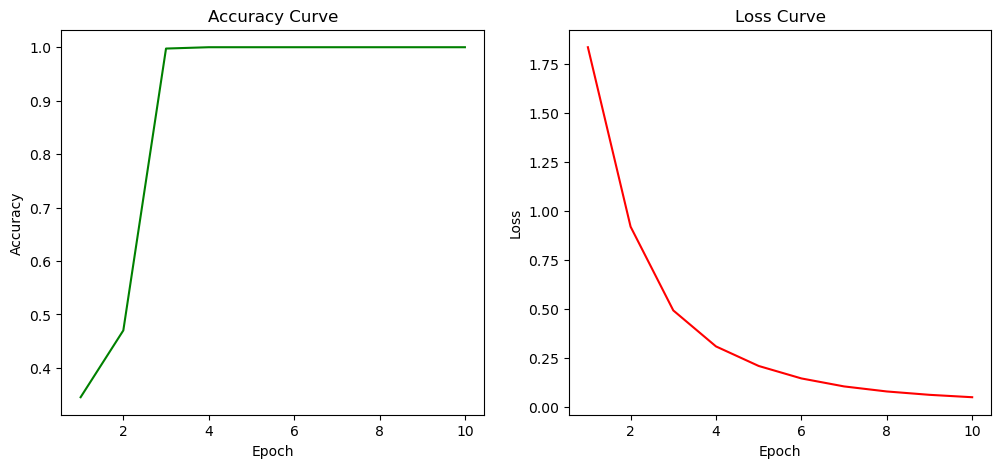

In [59]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(Epoch, Accuracy, c="green")
ax[0].set_title("Accuracy Curve")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Accuracy")
ax[1].plot(Epoch, Loss, c="red")
ax[1].set_title("Loss Curve")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
plt.show()